In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 让图表更清晰
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 读取数据
df = pd.read_csv("ai_models_performance.csv")

# 查看前几行
print(df.head())

# 查看基本信息
print(df.info())

# 查看描述统计
print(df.describe(include="all"))

                         Model Context Window    Creator Intelligence Index  \
0              GPT-5.2 (xhigh)           400k     OpenAI                 51   
1              Claude Opus 4.5           200k  Anthropic                 49   
2  Gemini 3 Pro Preview (high)             1m     Google                 48   
3               GPT-5.1 (high)           400k     OpenAI                 47   
4               Gemini 3 Flash             1m     Google                 46   

  Price (Blended USD/1M Tokens)  Speed(median token/s)  \
0                        $4.81                     100   
1                       $10.00                      79   
2                        $4.50                     128   
3                        $3.44                     127   
4                        $1.13                     224   

   Latency (First Answer Chunk /s)  
0                            44.29  
1                             1.70  
2                            32.19  
3                           

In [2]:
# 复制一份，避免直接改原始数据
data = df.copy()

# 重命名列，后面写代码更方便
data = data.rename(columns={
    "Model": "model",
    "Context Window": "context_window",
    "Creator": "creator",
    "Intelligence Index": "intelligence_index",
    "Price (Blended USD/1M Tokens)": "price",
    "Speed(median token/s)": "speed",
    "Latency (First Answer Chunk /s)": "latency"
})

# 清理 price 列：去掉 $
data["price"] = data["price"].replace(r"[\$,]", "", regex=True).astype(float)

# 检查缺失值
print(data.isnull().sum())

# 再看一下数据类型
print(data.dtypes)

model                 0
context_window        0
creator               0
intelligence_index    0
price                 0
speed                 0
latency               0
dtype: int64
model                  object
context_window         object
creator                object
intelligence_index     object
price                 float64
speed                   int64
latency               float64
dtype: object


In [3]:
# 不同厂商的模型数量
creator_counts = data["creator"].value_counts()
print(creator_counts)

# 各指标的最大最小值
print("最贵模型：")
print(data.loc[data["price"].idxmax(), ["model", "creator", "price"]])

print("\n最快模型：")
print(data.loc[data["speed"].idxmax(), ["model", "creator", "speed"]])

print("\n智能指数最高模型：")
print(data.loc[data["intelligence_index"].idxmax(), ["model", "creator", "intelligence_index"]])

creator
Alibaba                                  28
Google                                   14
OpenAI                                   13
NVIDIA                                   13
Mistral                                  12
Amazon                                   11
DeepSeek                                  9
xAI                                       8
Anthropic                                 6
IBM                                       6
LG AI Research                            6
Meta                                      6
Nous Research                             6
Z AI                                      5
Allen Institute for AI                    4
InclusionAI                               4
MBZUAI Institute of Foundation Models     3
Liquid AI                                 3
AI21 Labs                                 3
Kimi                                      3
Microsoft Azure                           3
Xiaomi                                    2
Upstage                 

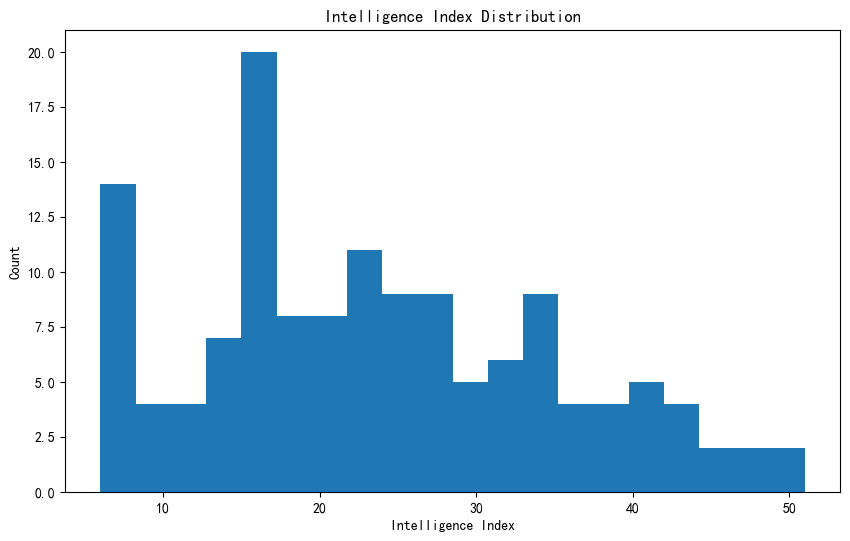

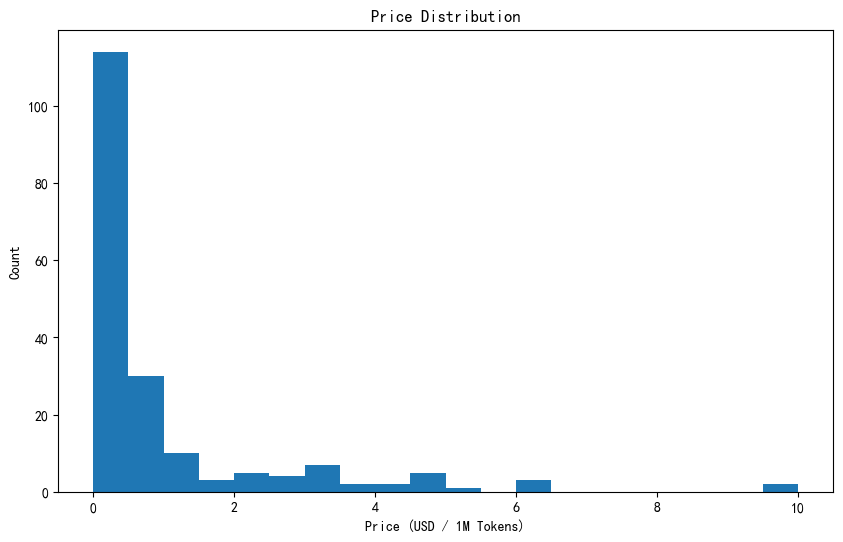

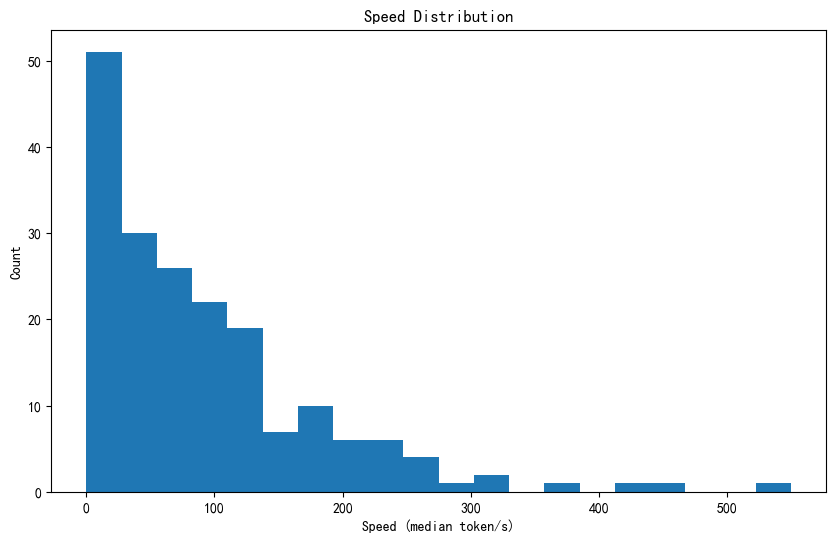

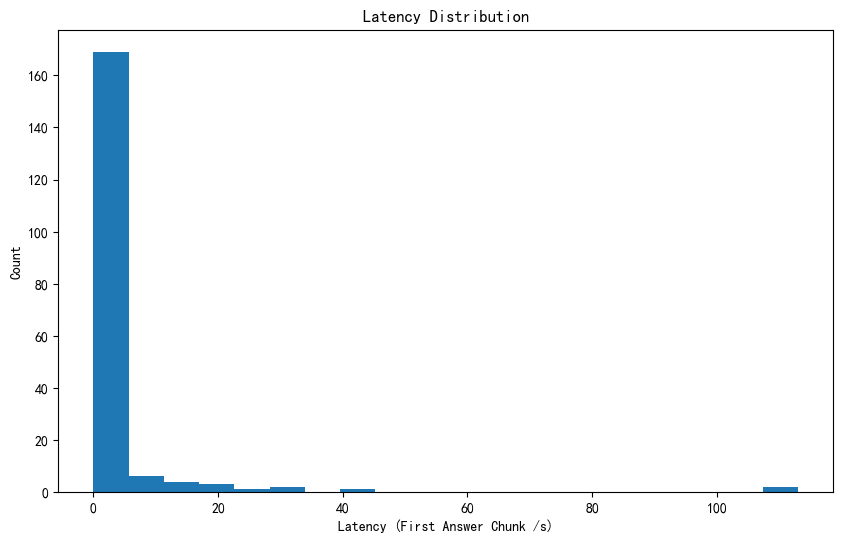

In [4]:
data["intelligence_index"] = pd.to_numeric(data["intelligence_index"], errors="coerce")

# 1. Intelligence Index 分布
plt.hist(data["intelligence_index"], bins=20)
plt.title("Intelligence Index Distribution")
plt.xlabel("Intelligence Index")
plt.ylabel("Count")
plt.show()

# 2. 价格分布
plt.hist(data["price"], bins=20)
plt.title("Price Distribution")
plt.xlabel("Price (USD / 1M Tokens)")
plt.ylabel("Count")
plt.show()

# 3. 速度分布
plt.hist(data["speed"], bins=20)
plt.title("Speed Distribution")
plt.xlabel("Speed (median token/s)")
plt.ylabel("Count")
plt.show()

# 4. 延迟分布
plt.hist(data["latency"], bins=20)
plt.title("Latency Distribution")
plt.xlabel("Latency (First Answer Chunk /s)")
plt.ylabel("Count")
plt.show()

In [5]:
top_intelligence = data.sort_values("intelligence_index", ascending=False)[
    ["model", "creator", "intelligence_index", "price", "speed", "latency"]
].head(10)

print(top_intelligence)

                         model    creator  intelligence_index  price  speed  \
0              GPT-5.2 (xhigh)     OpenAI                51.0   4.81    100   
1              Claude Opus 4.5  Anthropic                49.0  10.00     79   
2  Gemini 3 Pro Preview (high)     Google                48.0   4.50    128   
3               GPT-5.1 (high)     OpenAI                47.0   3.44    127   
4               Gemini 3 Flash     Google                46.0   1.13    224   
5             GPT-5.2 (medium)     OpenAI                45.0   4.81      0   
6              Claude Opus 4.5  Anthropic                43.0  10.00     72   
7            Claude 4.5 Sonnet  Anthropic                42.0   6.00     80   
8                      GLM-4.7       Z AI                42.0   0.94     78   
9         GPT-5.1 Codex (high)     OpenAI                42.0   3.44    190   

   latency  
0    44.29  
1     1.70  
2    32.19  
3    26.50  
4    11.62  
5     0.00  
6     1.96  
7     1.60  
8     0.61  


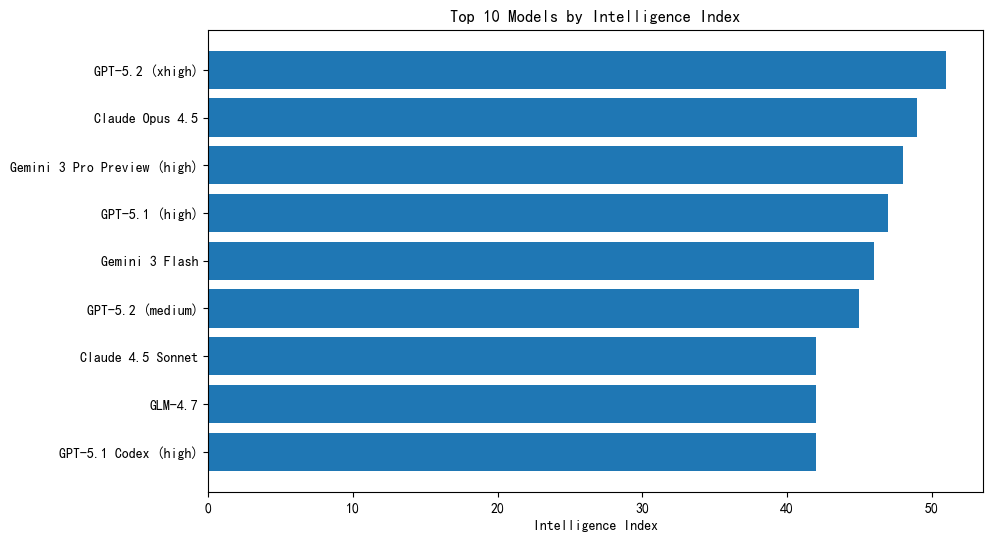

In [6]:
top10 = data.sort_values("intelligence_index", ascending=False).head(10)

plt.barh(top10["model"], top10["intelligence_index"])
plt.title("Top 10 Models by Intelligence Index")
plt.xlabel("Intelligence Index")
plt.gca().invert_yaxis()
plt.show()

当前高性能模型主要集中在 OpenAI、Anthropic 和 Google，市场呈现明显的头部集中格局。其中 OpenAI 仍保持性能领先，但 Google 的 Gemini 系列已经在高端能力上非常接近。

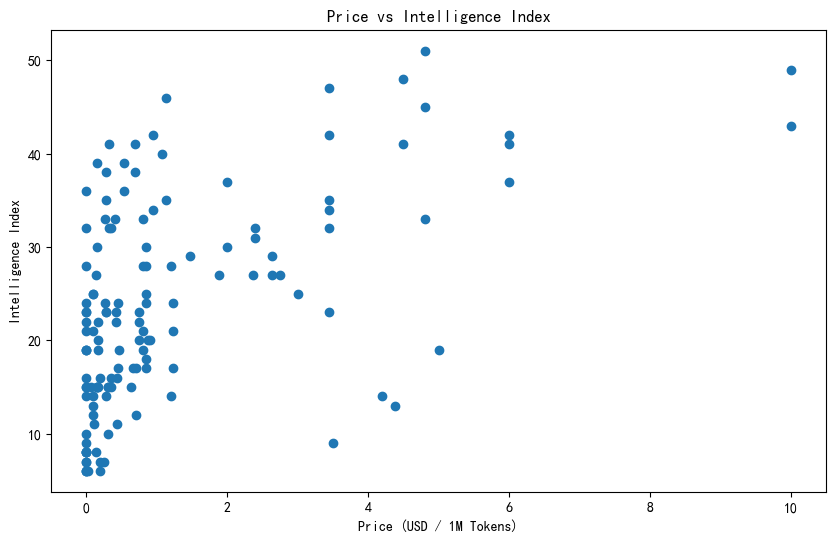

In [7]:
plt.scatter(data["price"], data["intelligence_index"])
plt.title("Price vs Intelligence Index")
plt.xlabel("Price (USD / 1M Tokens)")
plt.ylabel("Intelligence Index")
plt.show()

In [8]:
print(data["intelligence_index"].head(20))

0     51.0
1     49.0
2     48.0
3     47.0
4     46.0
5     45.0
6     43.0
7     42.0
8     42.0
9     42.0
10    41.0
11    41.0
12     NaN
13    41.0
14    41.0
15    40.0
16    39.0
17    39.0
18    38.0
19    38.0
Name: intelligence_index, dtype: float64


In [9]:
# 提取数字部分
data["intelligence_index"] = data["intelligence_index"].astype(str).str.extract(r'(\d+)')

# 转成 float
data["intelligence_index"] = data["intelligence_index"].astype(float)

In [10]:
# 看看有没有变成 NaN
print(data["intelligence_index"].isnull().sum())

# 如果有，直接删掉
data = data.dropna(subset=["intelligence_index"])

51


In [11]:
corr_price_intelligence = data["price"].corr(data["intelligence_index"])
print("价格与智能指数相关系数：", corr_price_intelligence)

价格与智能指数相关系数： 0.5322093183534102


高端模型之间的性能差距正在缩小，但价格差异仍然很大，因此绝对性能已经不是唯一决策因素，成本效率也应当成为重要的参考指标。

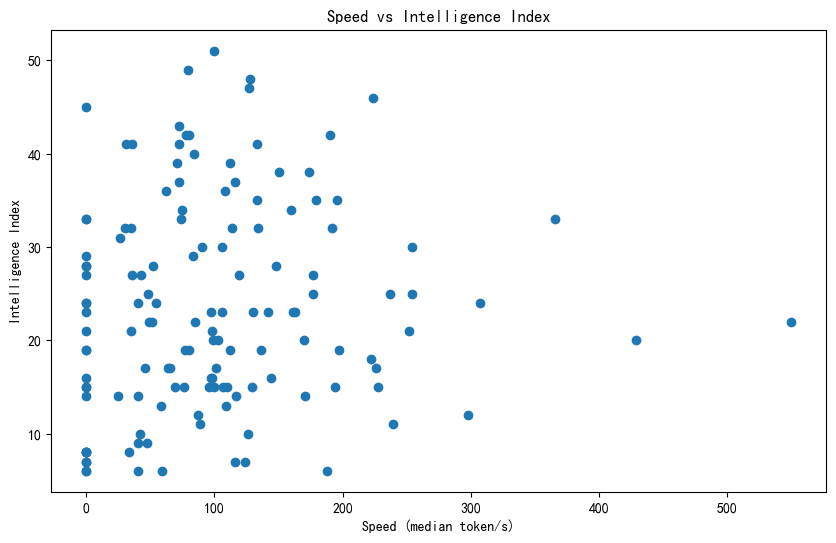

速度与智能指数相关系数： 0.10374555266734996


In [12]:
plt.scatter(data["speed"], data["intelligence_index"])
plt.title("Speed vs Intelligence Index")
plt.xlabel("Speed (median token/s)")
plt.ylabel("Intelligence Index")
plt.show()

corr_speed_intelligence = data["speed"].corr(data["intelligence_index"])
print("速度与智能指数相关系数：", corr_speed_intelligence)

这个值非常低，说明：在这份数据里，速度和性能几乎没有明显线性关系。  
这点非常重要，因为它打破了一个很常见的直觉：很多人会以为“性能越强一定越慢”，但这份数据并不支持这种简单判断。  
大多数模型并没有落入“高性能必然低速度”的传统 trade-off，而是在性能和速度之间实现了更好的平衡。

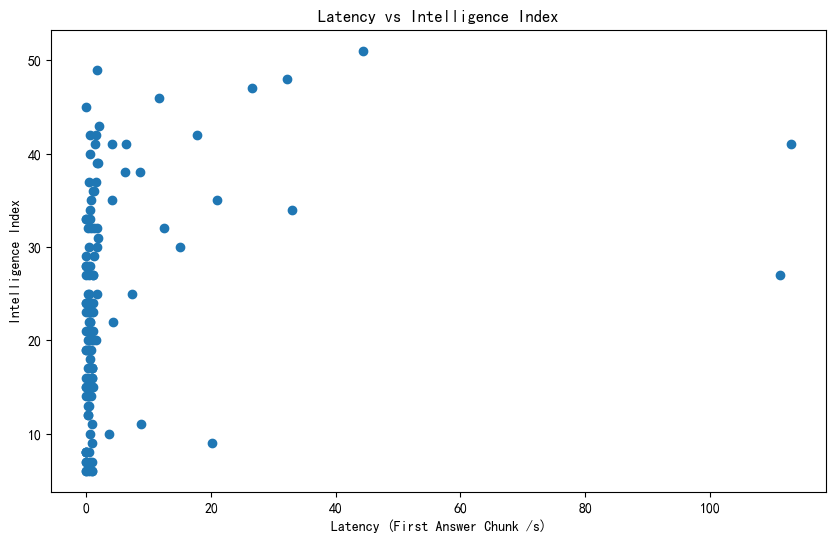

延迟与智能指数相关系数： 0.28841492654364503


In [13]:
plt.scatter(data["latency"], data["intelligence_index"])
plt.title("Latency vs Intelligence Index")
plt.xlabel("Latency (First Answer Chunk /s)")
plt.ylabel("Intelligence Index")
plt.show()

corr_latency_intelligence = data["latency"].corr(data["intelligence_index"])
print("延迟与智能指数相关系数：", corr_latency_intelligence)

这个值比速度略高，但仍然不算强，只能说明二者存在较弱的正相关。由此可以判断延迟与性能之间存在一定关系，但相关性较弱。  
模型的响应体验并不只取决于性能，还会受到推理架构、部署方式和系统优化等因素影响。  
另外数据中存在个别异常值（GPT-5.2 (medium) 的 speed = 0），它很可能不是正常业务值，更像缺失或记录异常。

In [14]:
free_models = data[data["price"] == 0].copy()
paid_models = data[data["price"] > 0].copy()

print("免费/零价格模型数量：", len(free_models))
print("付费模型数量：", len(paid_models))

免费/零价格模型数量： 26
付费模型数量： 111


In [15]:
paid_models["value_score"] = paid_models["intelligence_index"] / paid_models["price"]

top_value_paid = paid_models.sort_values("value_score", ascending=False)[
    ["model", "creator", "intelligence_index", "price", "value_score"]
].head(10)

print(top_value_paid)

                          model creator  intelligence_index  price  \
17                MiMo-V2-Flash  Xiaomi                39.0   0.15   
58           gpt-oss-20B (high)  OpenAI                25.0   0.10   
59       NVIDIA Nemotron 3 Nano  NVIDIA                25.0   0.10   
119  NVIDIA Nemotron Nano 9B V2  NVIDIA                15.0   0.07   
81            gpt-oss-20B (low)  OpenAI                21.0   0.10   
41                MiMo-V2-Flash  Xiaomi                30.0   0.15   
179                Gemma 3n E4B  Google                 6.0   0.03   
53            GPT-5 nano (high)  OpenAI                27.0   0.14   
139      NVIDIA Nemotron 3 Nano  NVIDIA                14.0   0.10   
18                Grok 4.1 Fast     xAI                38.0   0.28   

     value_score  
17    260.000000  
58    250.000000  
59    250.000000  
119   214.285714  
81    210.000000  
41    200.000000  
179   200.000000  
53    192.857143  
139   140.000000  
18    135.714286  


高性能模型负责“冲顶”，高性价比模型负责“落地”。  
MiMo-V2-Flash 是一个非常值得点名的模型,在保持较强性能的同时，把价格压得非常低，因此呈现出极强的成本效率优势。  
OpenAI 不仅在高端性能上领先，也在低成本模型布局上保持竞争力，产品线覆盖较完整。

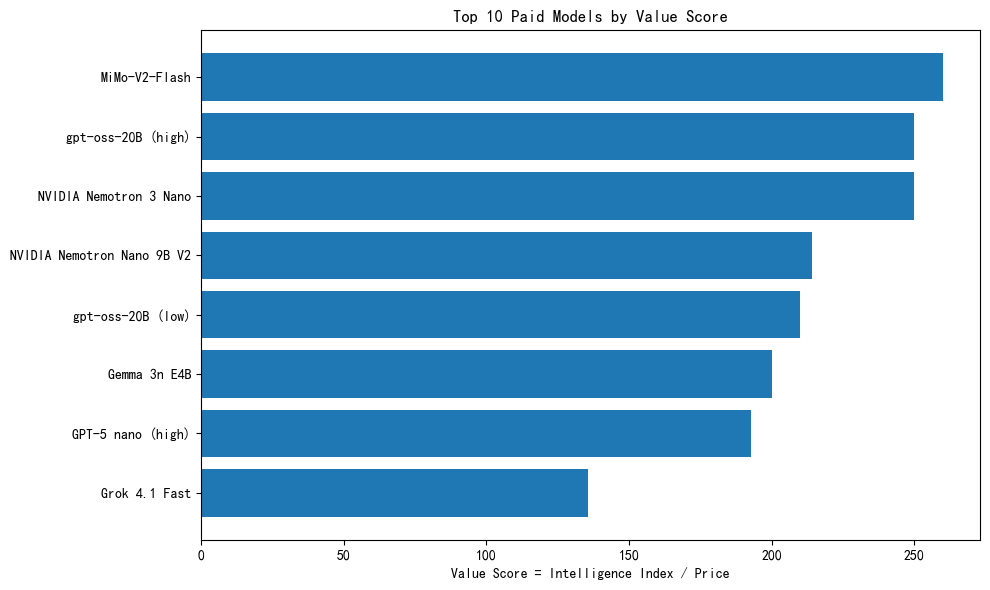

In [16]:
# 1. 计算性价比
paid_models["value_score"] = paid_models["intelligence_index"] / paid_models["price"]

# 2. 清理异常值
paid_models = paid_models.replace([np.inf, -np.inf], np.nan)
paid_models = paid_models.dropna(subset=["value_score"])

# 3. 取 Top 10
top_value = paid_models.sort_values("value_score", ascending=False).head(10)

# 4. 画图（关键：加 tight_layout）
plt.figure(figsize=(10, 6))
plt.barh(top_value["model"], top_value["value_score"])
plt.title("Top 10 Paid Models by Value Score")
plt.xlabel("Value Score = Intelligence Index / Price")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
top_free_models = free_models.sort_values("intelligence_index", ascending=False)[
    ["model", "creator", "intelligence_index", "speed", "latency"]
].head(10)

print(top_free_models)

                            model                                creator  \
22               KAT-Coder-Pro V1                                KwaiKAT   
37                       K-EXAONE                         LG AI Research   
49        Apriel-v1.6-15B-Thinker                             ServiceNow   
61  HyperCLOVA X SEED Think (32B)                                  Naver   
68                Mi:dm K 2.5 Pro                          Korea Telecom   
69                       K-EXAONE                         LG AI Research   
78                     Devstral 2                                Mistral   
82                   K2-V2 (high)  MBZUAI Institute of Foundation Models   
92                        Ling-1T                            InclusionAI   
93               Devstral Small 2                                Mistral   

    intelligence_index  speed  latency  
22                36.0     62     1.09  
37                32.0    114     0.31  
49                28.0    148     0.28  

In [18]:
analysis = data.copy()

# 标准化
analysis["intelligence_norm"] = (analysis["intelligence_index"] - analysis["intelligence_index"].min()) / (
    analysis["intelligence_index"].max() - analysis["intelligence_index"].min()
)

analysis["speed_norm"] = (analysis["speed"] - analysis["speed"].min()) / (
    analysis["speed"].max() - analysis["speed"].min()
)

# 价格越低越好，所以取反向分数
analysis["price_norm"] = 1 - (
    (analysis["price"] - analysis["price"].min()) /
    (analysis["price"].max() - analysis["price"].min())
)

# 如果 latency 越低越好，也做反向标准化
analysis["latency_norm"] = 1 - (
    (analysis["latency"] - analysis["latency"].min()) /
    (analysis["latency"].max() - analysis["latency"].min())
)

# 自定义综合评分
analysis["overall_score"] = (
    analysis["intelligence_norm"] * 0.5 +
    analysis["speed_norm"] * 0.2 +
    analysis["price_norm"] * 0.2 +
    analysis["latency_norm"] * 0.1
)

top_overall = analysis.sort_values("overall_score", ascending=False)[
    ["model", "creator", "intelligence_index", "price", "speed", "latency", "overall_score"]
].head(10)

print(top_overall)

                          model   creator  intelligence_index  price  speed  \
4                Gemini 3 Flash    Google                46.0   1.13    224   
33          gpt-oss-120B (high)    OpenAI                33.0   0.26    366   
3                GPT-5.1 (high)    OpenAI                47.0   3.44    127   
8                       GLM-4.7      Z AI                42.0   0.94     78   
17                MiMo-V2-Flash    Xiaomi                39.0   0.15    112   
0               GPT-5.2 (xhigh)    OpenAI                51.0   4.81    100   
18                Grok 4.1 Fast       xAI                38.0   0.28    150   
19    GPT-5.1 Codex mini (high)    OpenAI                38.0   0.69    174   
2   Gemini 3 Pro Preview (high)    Google                48.0   4.50    128   
11                DeepSeek V3.2  DeepSeek                41.0   0.32     31   

    latency  overall_score  
4     11.62       0.793017  
33     0.41       0.727528  
3     26.50       0.709488  
8      0.61   

In [19]:
creator_summary = data.groupby("creator").agg({
    "intelligence_index": "mean",
    "price": "mean",
    "speed": "mean",
    "latency": "mean",
    "model": "count"
}).rename(columns={"model": "model_count"}).sort_values("intelligence_index", ascending=False)

print(creator_summary)

                                       intelligence_index     price  \
creator                                                               
Anthropic                                       39.666667  6.000000   
MiniMax                                         37.500000  0.530000   
KwaiKAT                                         36.000000  0.000000   
OpenAI                                          35.583333  1.962500   
Xiaomi                                          34.500000  0.150000   
Kimi                                            34.000000  1.135000   
ByteDance Seed                                  33.000000  0.410000   
DeepSeek                                        32.200000  0.920000   
xAI                                             32.000000  1.245000   
Baidu                                           29.000000  1.470000   
ServiceNow                                      28.000000  0.000000   
Z AI                                            28.000000  0.640000   
Google

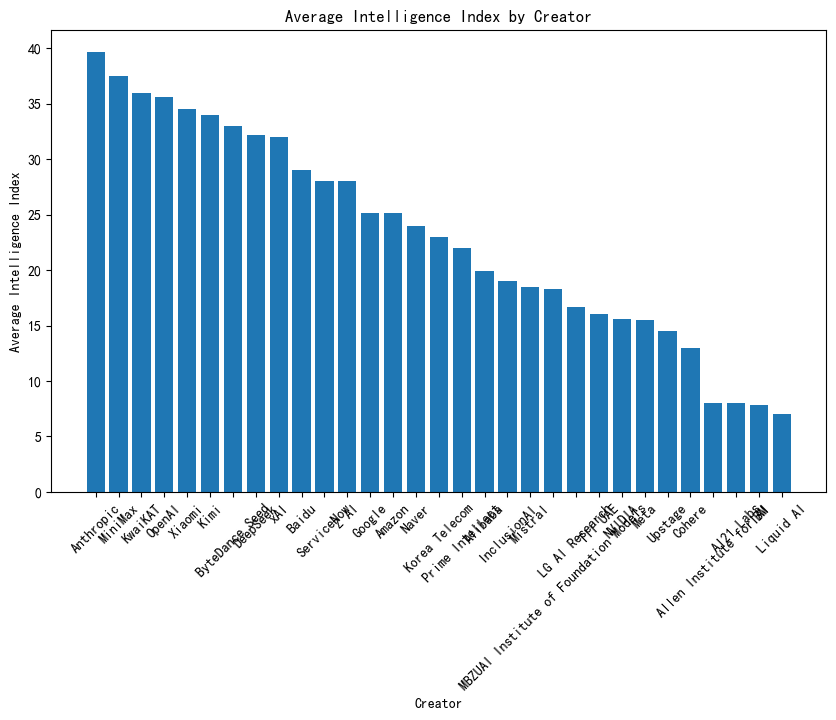

In [20]:
creator_avg = data.groupby("creator")["intelligence_index"].mean().sort_values(ascending=False)

plt.bar(creator_avg.index, creator_avg.values)
plt.title("Average Intelligence Index by Creator")
plt.xlabel("Creator")
plt.ylabel("Average Intelligence Index")
plt.xticks(rotation=45)
plt.show()

如果从单模型峰值来看，OpenAI 仍然领先；但从厂商整体平均能力来看，Anthropic 的模型组合表现更稳定，平均性能位列第一。  
除了传统头部厂商之外，一些中国厂商在模型性能上也展现出较强竞争力。  
厂商平均性能能够反映整体水平，但仍需结合模型数量与样本覆盖范围综合解读。

In [21]:
best_performance = data.sort_values("intelligence_index", ascending=False).head(5)
print(best_performance[["model", "creator", "intelligence_index", "price"]])

                         model    creator  intelligence_index  price
0              GPT-5.2 (xhigh)     OpenAI                51.0   4.81
1              Claude Opus 4.5  Anthropic                49.0  10.00
2  Gemini 3 Pro Preview (high)     Google                48.0   4.50
3               GPT-5.1 (high)     OpenAI                47.0   3.44
4               Gemini 3 Flash     Google                46.0   1.13


In [22]:
lowest_price = data.sort_values("price", ascending=True).head(5)
print(lowest_price[["model", "creator", "price", "intelligence_index"]])

                            model         creator  price  intelligence_index
22               KAT-Coder-Pro V1         KwaiKAT    0.0                36.0
61  HyperCLOVA X SEED Think (32B)           Naver    0.0                24.0
49        Apriel-v1.6-15B-Thinker      ServiceNow    0.0                28.0
37                       K-EXAONE  LG AI Research    0.0                32.0
68                Mi:dm K 2.5 Pro   Korea Telecom    0.0                23.0


In [23]:
best_value = paid_models.sort_values("value_score", ascending=False).head(5)
print(best_value[["model", "creator", "value_score", "price", "intelligence_index"]])

                          model creator  value_score  price  \
17                MiMo-V2-Flash  Xiaomi   260.000000   0.15   
58           gpt-oss-20B (high)  OpenAI   250.000000   0.10   
59       NVIDIA Nemotron 3 Nano  NVIDIA   250.000000   0.10   
119  NVIDIA Nemotron Nano 9B V2  NVIDIA   214.285714   0.07   
81            gpt-oss-20B (low)  OpenAI   210.000000   0.10   

     intelligence_index  
17                 39.0  
58                 25.0  
59                 25.0  
119                15.0  
81                 21.0  


In [24]:
top_overall.to_csv("top_overall_models.csv", index=False)
top_value.to_csv("top_value_models.csv", index=False)
creator_summary.to_csv("creator_summary.csv")